<a href="https://colab.research.google.com/github/AI-is-out-there/SkillFactory-DataScience-MED/blob/main/code/part-1-NN_overfitting_simple_dataset_load.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ucimlrepo -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from ucimlrepo import fetch_ucirepo

# 1. Загрузка данных

In [ ]:

print("Загрузка датасета Iris...")
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)
# variable information
print(iris.variables)

# Объединяем признаки и таргеты в один DataFrame для удобства
dataset = pd.concat([X, y], axis=1)
# Переименуем колонки для единообразия (названия могут отличаться в зависимости от версии репозитория)
dataset.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

# 2. Визуальный анализ данных (pairplot)


Построение pairplot...


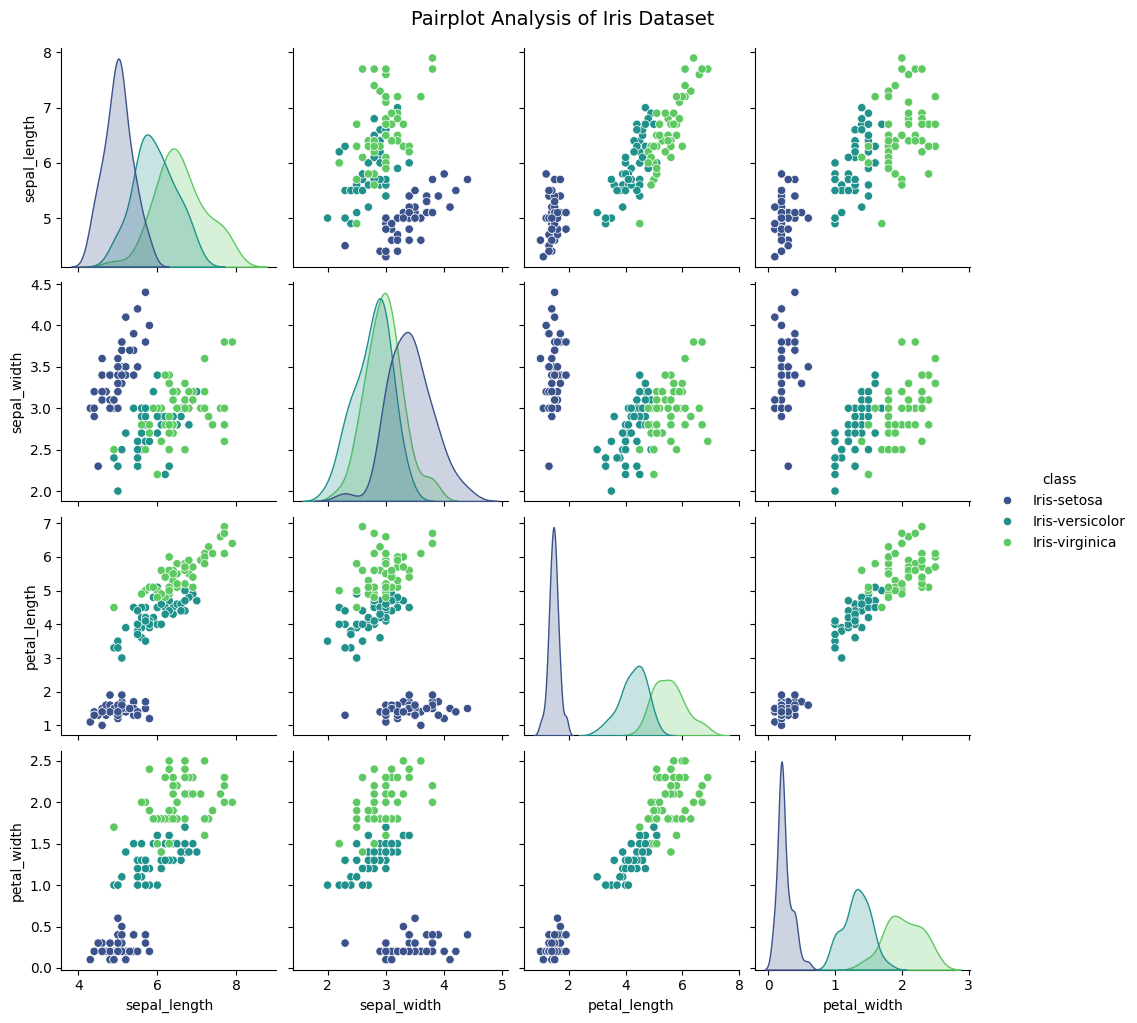

In [4]:
print("\nПостроение pairplot...")
sns.pairplot(dataset, hue='class', palette='viridis')
plt.suptitle('Pairplot Analysis of Iris Dataset', y=1.02, fontsize=14)
plt.show()

# 3. LogisticRegression для бинарной классификации


In [5]:

print("\nОбучение бинарного классификатора...")
# Оставим только два класса: versicolor и virginica
binary_dataset = dataset[dataset['class'] != 'Iris-setosa'].copy()

X_bin = binary_dataset.drop('class', axis=1)
y_bin = binary_dataset['class']

# Кодирование классов: -1 для versicolor, 1 для virginica
y_bin = y_bin.map({'Iris-versicolor': -1, 'Iris-virginica': 1})

# Обучение модели
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_bin, y_bin)

print(f"✅ Модель обучена. Веса: {model_lr.coef_.flatten()} | Свободный член: {model_lr.intercept_[0]:.4f}")
print(f"   Accuracy на обучающей выборке: {model_lr.score(X_bin, y_bin):.2%}")


Обучение бинарного классификатора...
✅ Модель обучена. Веса: [-0.39629303 -0.5122079   2.93019683  2.41380088] | Свободный член: -14.4140
   Accuracy на обучающей выборке: 96.00%


# 4. Демонстрация переобучения модели линейной регрессии



Демонстрация переобучения на реальных данных...


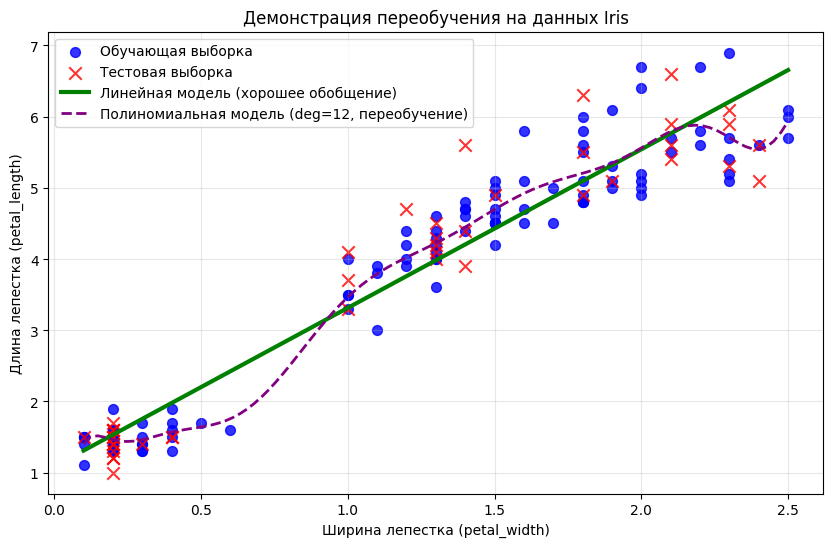


📊 Ошибки моделей (Mean Squared Error):
🟢 Линейная модель   -> Train MSE: 0.2120 | Test MSE: 0.2590
🟣 Полиномиальная   -> Train MSE: 0.1313 | Test MSE: 0.1367


In [6]:
print("\nДемонстрация переобучения на реальных данных...")
# Задача: предсказать petal_length по petal_width
reg_df = dataset[['petal_width', 'petal_length']].copy().sort_values('petal_width')

X_reg = reg_df[['petal_width']].values
y_reg = reg_df['petal_length'].values

# Разделение на train/test (30% данных пойдет на контроль)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# --- Адекватная модель (Линейная регрессия 1-й степени) ---
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# --- Переобученная модель (Полиномиальная регрессия высокой степени) ---
degree = 12
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Визуализация
x_plot = np.linspace(reg_df['petal_width'].min(), reg_df['petal_width'].max(), 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Обучающая выборка', s=50, alpha=0.8)
plt.scatter(X_test, y_test, color='red', marker='x', label='Тестовая выборка', s=80, alpha=0.8)

plt.plot(x_plot, lin_model.predict(x_plot), color='green', linewidth=3, label='Линейная модель (хорошее обобщение)')
plt.plot(x_plot, poly_model.predict(poly.transform(x_plot)), color='purple', linestyle='--', linewidth=2, label=f'Полиномиальная модель (deg={degree}, переобучение)')

plt.xlabel('Ширина лепестка (petal_width)')
plt.ylabel('Длина лепестка (petal_length)')
plt.title('Демонстрация переобучения на данных Iris')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Оценка качества (MSE)
print("\n📊 Ошибки моделей (Mean Squared Error):")
print(f"🟢 Линейная модель   -> Train MSE: {mean_squared_error(y_train, lin_model.predict(X_train)):.4f} | Test MSE: {mean_squared_error(y_test, lin_model.predict(X_test)):.4f}")
print(f"🟣 Полиномиальная   -> Train MSE: {mean_squared_error(y_train, poly_model.predict(X_train_poly)):.4f} | Test MSE: {mean_squared_error(y_test, poly_model.predict(X_test_poly)):.4f}")

# 5. Пример с нейронной сетью


Обучение простой нейронной сети (MLP) с демонстрацией переобучения...


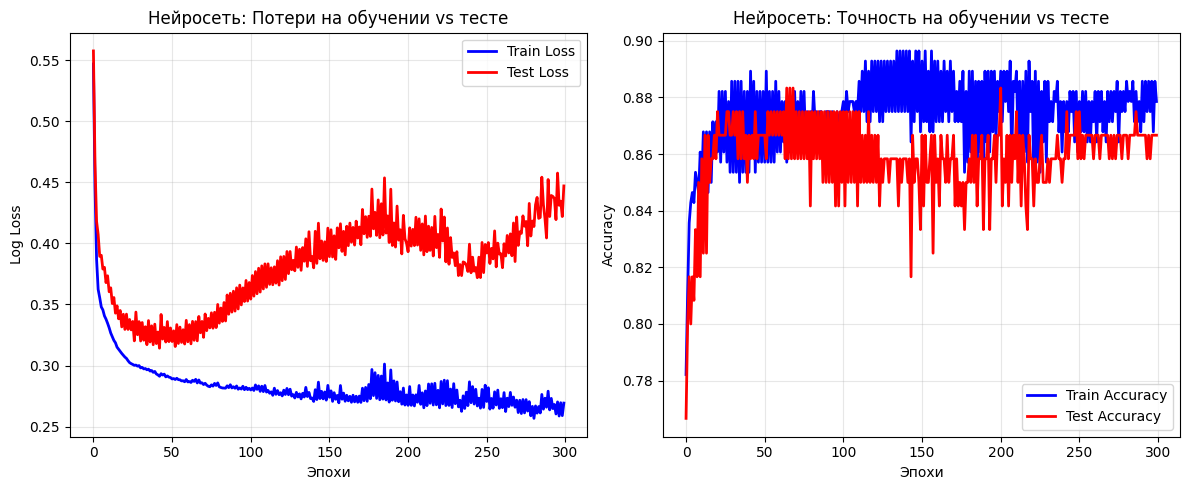


Итоговые метрики (после 300 эпох):
Train -> Loss: 0.2692 | Accuracy: 0.879
Test  -> Loss: 0.4470 | Accuracy: 0.867

Наблюдается классическое переобучение:
   - Модель 'запоминает' шум обучающей выборки (Train Accuracy → 1.0, Loss → 0.0)
   - На новых данных качество падает, а ошибка растет (дивергенция кривых)
   Способы борьбы: alpha>0.01 (регуляризация), EarlyStopping, уменьшение hidden_layer_sizes, увеличение данных.


In [9]:
import warnings
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Filter out ConvergenceWarning from sklearn
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("\nОбучение простой нейронной сети (MLP) с демонстрацией переобучения...")

# 1. Генерация данных с шумом (30% пойдут на контроль)
X_syn, y_syn = make_moons(n_samples=400, noise=0.35, random_state=42)
X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(X_syn, y_syn, test_size=0.3, random_state=42)

# 2. Настройка модели для переобучения:
#    - Большая архитектура (50, 50)
#    - alpha=0.0 (полное отсутствие L2-регуляризации)
#    - warm_start=True + max_iter=1 (позволяет контролировать каждую эпоху)
nn = MLPClassifier(hidden_layer_sizes=(50, 50), activation='relu',
                   solver='adam', alpha=0.0, learning_rate_init=0.01,
                   max_iter=1, warm_start=True, random_state=42, verbose=False)

epochs = 300
train_losses, test_losses = [], []
train_accs, test_accs = [], []

# 3. Пошаговое обучение с отслеживанием метрик
for epoch in range(epochs):
    nn.fit(X_syn_train, y_syn_train)

    # Вычисляем логарифмическую потерю и точность
    train_losses.append(log_loss(y_syn_train, nn.predict_proba(X_syn_train)))
    test_losses.append(log_loss(y_syn_test, nn.predict_proba(X_syn_test)))
    train_accs.append(nn.score(X_syn_train, y_syn_train))
    test_accs.append(nn.score(X_syn_test, y_syn_test))

# 4. Визуализация кривых обучения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(test_losses, label='Test Loss', color='red', linewidth=2)
plt.xlabel('Эпохи')
plt.ylabel('Log Loss')
plt.title('Нейросеть: Потери на обучении vs тесте')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', color='blue', linewidth=2)
plt.plot(test_accs, label='Test Accuracy', color='red', linewidth=2)
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.title('Нейросеть: Точность на обучении vs тесте')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Итоговая оценка
print(f"\nИтоговые метрики (после {epochs} эпох):")
print(f"Train -> Loss: {train_losses[-1]:.4f} | Accuracy: {train_accs[-1]:.3f}")
print(f"Test  -> Loss: {test_losses[-1]:.4f} | Accuracy: {test_accs[-1]:.3f}")
print("\nНаблюдается классическое переобучение:")
print("   - Модель 'запоминает' шум обучающей выборки (Train Accuracy → 1.0, Loss → 0.0)")
print("   - На новых данных качество падает, а ошибка растет (дивергенция кривых)")
print("   Способы борьбы: alpha>0.01 (регуляризация), EarlyStopping, уменьшение hidden_layer_sizes, увеличение данных.")